# Phase 1 -- Preprocessing

Lab experiment covering the preprocessing pipeline in `nticipate/preprocess.py`:
cleaning, sentence segmentation, tokenization, vocabulary/`<UNK>` handling,
and train/dev/test splitting.

This notebook runs against the small sample corpora in `data/raw/` so it
works out of the box with no downloads. Swap `CORPUS_SOURCE` to `"nltk"`
below once you've run `python setup_env.py` to reproduce the same
analysis on Brown + Gutenberg + Reuters (~3M tokens) for the real
submission numbers.


In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

from nticipate.config import load_config, resolve_path
from nticipate.preprocess import (
    clean_text, segment_sentences, tokenize,
    build_vocab, apply_unk, build_truecase_map, apply_truecase,
    pad_sentence, train_dev_test_split,
)

CFG = load_config()
CORPUS_SOURCE = "sample"   # "sample" (ships in repo) or "nltk" (after setup_env.py)


## 1. Load raw corpus

In [2]:
if CORPUS_SOURCE == "sample":
    with open(resolve_path("data/raw/sample_english.txt"), encoding="utf-8") as f:
        raw_text = f.read()
    raw_documents = [p for p in raw_text.split("\n\n") if p.strip()]
else:
    import nltk
    raw_documents = []
    for corpus_name in CFG["preprocessing"]["corpora_english"]:
        corpus = getattr(nltk.corpus, corpus_name)
        for fileid in corpus.fileids():
            raw_documents.append(corpus.raw(fileid))

print(f"Loaded {len(raw_documents)} document(s) from source '{CORPUS_SOURCE}'")
print("--- sample ---")
print(raw_documents[0][:200])

Loaded 20 document(s) from source 'sample'
--- sample ---
The cat sat on the mat. The dog ran in the park. The cat and the dog played together in the park.


## 2. Run the pipeline: clean -> segment -> tokenize

Each stage is timed and counted separately so the "before/after" table
in the report is easy to build.

In [3]:
naive_whitespace_tokens = sum(len(doc.split()) for doc in raw_documents)

cleaned_docs = [clean_text(doc) for doc in raw_documents]

all_sentences = []
for doc in cleaned_docs:
    all_sentences.extend(segment_sentences(doc))

tokenized_sentences = [tokenize(s) for s in all_sentences]
tokenized_sentences = [s for s in tokenized_sentences if s]  # drop empties

all_tokens = [tok for sent in tokenized_sentences for tok in sent]

print(f"Documents:                  {len(raw_documents)}")
print(f"Sentences after segmenting: {len(all_sentences)}")
print(f"Tokens (naive whitespace):  {naive_whitespace_tokens}")
print(f"Tokens (after tokenize()):  {len(all_tokens)}")

Documents:                  20
Sentences after segmenting: 60
Tokens (naive whitespace):  502
Tokens (after tokenize()):  575


**Note on the naive-vs-real token count gap**: `tokenize()` splits
punctuation into its own tokens (`"world!"` -> `"world"`, `"!"`), so the
real token count is consistently higher than a naive whitespace split.
That gap is itself worth reporting -- it's direct evidence the
tokenizer is doing more than `str.split()` would.

## 3. Vocabulary size vs. `min_freq`

This is the vocab coverage experiment: as the frequency threshold for
inclusion rises, vocabulary shrinks but so does the fraction of corpus
tokens it can represent without falling back to `<UNK>`.

In [4]:
thresholds = list(range(1, 11))
vocab_sizes = []
coverage_fractions = []

freq_counter = Counter(all_tokens)
total_tokens = len(all_tokens)

for thresh in thresholds:
    vocab = build_vocab(tokenized_sentences, min_freq=thresh)
    vocab_sizes.append(len(vocab))
    covered = sum(c for w, c in freq_counter.items() if c >= thresh)
    coverage_fractions.append(covered / total_tokens)

for t, v, c in zip(thresholds, vocab_sizes, coverage_fractions):
    print(f"min_freq={t:2d}  vocab_size={v:5d}  coverage={c:.4f}")

min_freq= 1  vocab_size=  286  coverage=1.0000
min_freq= 2  vocab_size=   71  coverage=0.6052
min_freq= 3  vocab_size=   33  coverage=0.4626
min_freq= 4  vocab_size=   19  coverage=0.4000
min_freq= 5  vocab_size=   16  coverage=0.3861
min_freq= 6  vocab_size=   15  coverage=0.3687
min_freq= 7  vocab_size=   13  coverage=0.3478
min_freq= 8  vocab_size=   11  coverage=0.3235
min_freq= 9  vocab_size=   11  coverage=0.3235
min_freq=10  vocab_size=    9  coverage=0.2922


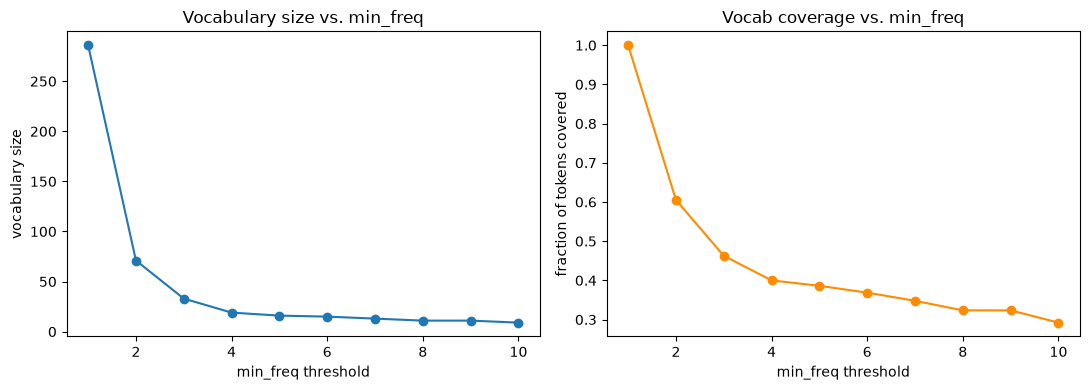

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(thresholds, vocab_sizes, marker="o")
ax1.set_xlabel("min_freq threshold")
ax1.set_ylabel("vocabulary size")
ax1.set_title("Vocabulary size vs. min_freq")

ax2.plot(thresholds, coverage_fractions, marker="o", color="darkorange")
ax2.set_xlabel("min_freq threshold")
ax2.set_ylabel("fraction of tokens covered")
ax2.set_title("Vocab coverage vs. min_freq")

fig.tight_layout()
plt.show()

## 4. Zipf's law check

Word frequency should fall off roughly linearly on a log-log rank/frequency
plot. This is the standard sanity check that the tokenizer is producing
a real natural-language token distribution, not an artifact of a bug.

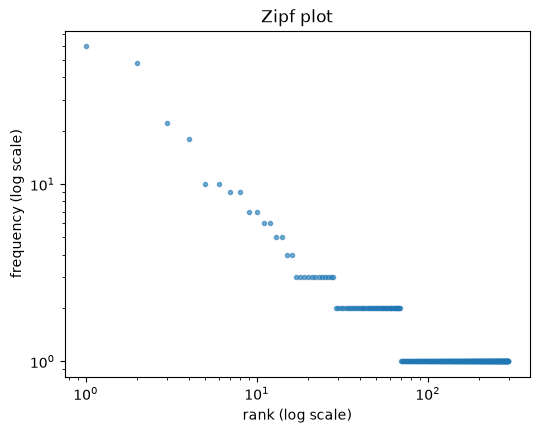

Top 10 most frequent tokens:
  '.'        60
  'the'      48
  'The'      22
  'and'      18
  'a'        10
  'of'       10
  'to'       9
  ','        9
  'in'       7
  'for'      7


In [6]:
freqs = sorted(freq_counter.values(), reverse=True)
ranks = np.arange(1, len(freqs) + 1)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(ranks, freqs, marker=".", linestyle="none", alpha=0.6)
ax.set_xlabel("rank (log scale)")
ax.set_ylabel("frequency (log scale)")
ax.set_title("Zipf plot")
plt.show()

print("Top 10 most frequent tokens:")
for word, count in freq_counter.most_common(10):
    print(f"  {word!r:10s} {count}")

## 5. Type-token ratio (TTR)

In [7]:
types = set(all_tokens)
ttr = len(types) / len(all_tokens)
print(f"Types:  {len(types)}")
print(f"Tokens: {len(all_tokens)}")
print(f"TTR:    {ttr:.4f}")

Types:  296
Tokens: 575
TTR:    0.5148


TTR falls as corpus size grows (more tokens means more repetition of
common words), so this number is only meaningful *relative to corpus
size* -- re-run this cell after switching `CORPUS_SOURCE = "nltk"` and
compare. It becomes directly useful in Phase 5, where Hindi/Marathi's
higher TTR (due to inflectional morphology) is the key comparison
against English.

## 6. `<UNK>` application and padding demo

A worked example showing the full per-sentence transformation before
it goes into n-gram counting (Phase 2).

Counting happens on lowercased tokens (`CFG['preprocessing']['lowercase_for_counts']`), so `apply_unk` returns lowercased text -- `"The"` and `"the"` are the same n-gram context. `apply_truecase` restores natural casing using the majority spelling seen in the corpus, for display back to the user.


In [8]:
demo_vocab = build_vocab(tokenized_sentences, min_freq=CFG["preprocessing"]["min_token_freq"])
demo_truecase_map = build_truecase_map(tokenized_sentences)
demo_sentence = tokenized_sentences[0]

unk_applied_demo = apply_unk(demo_sentence, demo_vocab)

print("Original:            ", demo_sentence)
print("<UNK> applied:       ", unk_applied_demo)
print("Padded (n=3):        ", pad_sentence(unk_applied_demo, n=3))
print("Truecased (round-trip):", apply_truecase(unk_applied_demo, demo_truecase_map))


Original:             ['The', 'cat', 'sat', 'on', 'the', 'mat', '.']
<UNK> applied:        ['the', 'cat', '<UNK>', 'on', 'the', '<UNK>', '.']
Padded (n=3):         ['<s>', '<s>', 'the', 'cat', '<UNK>', 'on', 'the', '<UNK>', '.', '</s>']
Truecased (round-trip): ['the', 'cat', '<UNK>', 'on', 'the', '<UNK>', '.']


## 7. Train/dev/test split

Uses `CFG['preprocessing']` ratios (80/10/10 by default) and a fixed
seed (`CFG['project']['seed']`) for reproducibility.

In [9]:
train, dev, test = train_dev_test_split(tokenized_sentences)
print(f"Train: {len(train)} sentences")
print(f"Dev:   {len(dev)} sentences")
print(f"Test:  {len(test)} sentences")

Train: 48 sentences
Dev:   6 sentences
Test:  6 sentences


## 8. Devanagari path: danda segmentation

Same pipeline, but on `data/raw/sample_hindi.txt`, exercising the
danda-aware (`।` / `॥`) sentence segmenter used by Phase 5.

In [10]:
with open(resolve_path("data/raw/sample_hindi.txt"), encoding="utf-8") as f:
    hindi_raw = f.read()

hindi_cleaned = clean_text(hindi_raw)
hindi_sentences = segment_sentences(hindi_cleaned)
hindi_tokenized = [tokenize(s) for s in hindi_sentences]

print(f"Hindi sentences: {len(hindi_sentences)}")
print("First sentence: ", hindi_sentences[0])
print("Tokenized:      ", hindi_tokenized[0])

Hindi sentences: 15
First sentence:  राम बाजार गया।
Tokenized:       ['राम', 'बाजार', 'गया', '।']


## Summary table (paste into report)

| Metric | Value |
|---|---|
| Documents | see cell 3 output |
| Sentences | see cell 3 output |
| Tokens (naive split) | see cell 3 output |
| Tokens (real tokenizer) | see cell 3 output |
| Vocab size (min_freq=1) | see cell 4 output |
| Vocab size (configured min_freq) | see cell 4 output |
| Type-token ratio | see cell 5 output |

Re-run this notebook with `CORPUS_SOURCE = "nltk"` to fill in the real
submission numbers once `python setup_env.py` has downloaded the full
corpora.